In [ ]:
#Lab 3. Logistic Regression
#Given a suitable classification dataset:
#a) Identify the input features and target variable and split the dataset into training and testing sets.
#b) Build and train a Logistic Regression model.
#c) Explain the role of the sigmoid function in converting the model output into probability.
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.
#e) Evaluate the model using a confusion matrix and suitable classification measures.
#f) Plot the ROC curve and calculate AUC, where applicable.
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.


In [2]:
#a) Identify the input features and target variable and split the dataset into training and testing sets.

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("04_diabetes_diagnosis.csv")

# Input features = all columns except the target
X = df.drop("has_diabetes", axis=1)

# Target variable = has_diabetes
# 0 = No Diabetes
# 1 = Diabetes
y = df["has_diabetes"]

# Convert categorical columns into numbers
# Logistic Regression works with numerical data
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing data
# 80% -> Training
# 20% -> Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 9)
Testing data: (60, 9)


In [3]:
#b) Build and train a Logistic Regression model.

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [4]:
#c) Explain the role of the sigmoid function in converting the model output into probability.

# Logistic Regression uses the Sigmoid function.
# Sigmoid converts the model's output into a probability between 0 and 1.
#
# Probability close to 1 -> Higher chance of Diabetes
# Probability close to 0 -> Lower chance of Diabetes

probabilities = model.predict_proba(X_test)

print("Probabilities:")
print(probabilities[:5])

Probabilities:
[[0.90628491 0.09371509]
 [0.20800564 0.79199436]
 [0.41129237 0.58870763]
 [0.94335439 0.05664561]
 [0.60052547 0.39947453]]


In [5]:
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.

# Predict class labels
# 0 = No Diabetes
# 1 = Diabetes
y_pred = model.predict(X_test)

# Get probability of class 1 (Diabetes)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted class labels:")
print(y_pred[:10])

print("\nProbability of Diabetes:")
print(y_prob[:10])

# Default classification threshold = 0.50
threshold = 0.50

# If probability >= 0.50 -> predict 1 (Diabetes)
# If probability < 0.50 -> predict 0 (No Diabetes)
threshold_predictions = (y_prob >= threshold).astype(int)

print("\nPredictions using threshold 0.50:")
print(threshold_predictions[:10])

Predicted class labels:
[0 1 1 0 0 1 1 1 0 1]

Probability of Diabetes:
[0.09371509 0.79199436 0.58870763 0.05664561 0.39947453 0.62248894
 0.68070139 0.50844232 0.13615737 0.90062339]

Predictions using threshold 0.50:
[0 1 1 0 0 1 1 1 0 1]


In [6]:
#e) Evaluate the model using a confusion matrix and suitable classification measures.

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

# Calculate F1-Score
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Confusion Matrix:
[[24 10]
 [ 7 19]]

Accuracy: 0.7166666666666667
Precision: 0.6551724137931034
Recall: 0.7307692307692307
F1-Score: 0.6909090909090909


AUC Score: 0.7895927601809956


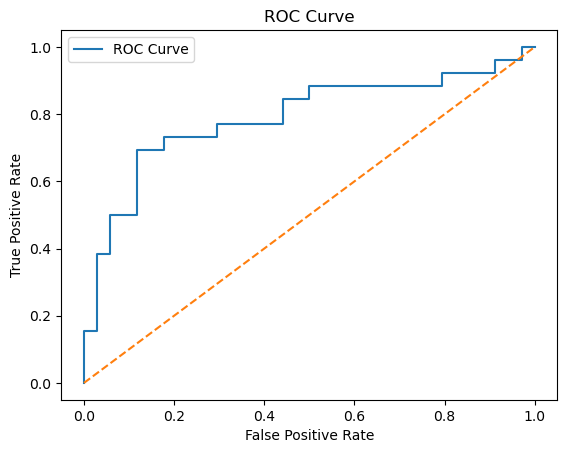

In [7]:
#f) Plot the ROC curve and calculate AUC, where applicable.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC Curve
plt.plot(fpr, tpr, label="ROC Curve")

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [8]:
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.


# Change threshold from 0.50 to 0.70
new_threshold = 0.70

# Probability >= 0.70 -> Diabetes (1)
# Probability < 0.70 -> No Diabetes (0)
new_threshold_predictions = (y_prob >= new_threshold).astype(int)

print("Predictions using threshold 0.70:")
print(new_threshold_predictions[:10])


# Create a new person/observation
new_observation = pd.DataFrame({
    "glucose_level": [150],
    "bmi": [30],
    "age_years": [50],
    "blood_pressure": [120],
    "gender": ["Female"],
    "smoking_status": ["Non-Smoker"],
    "blood_type": ["A"]
})

# Convert categorical values into numbers
new_observation = pd.get_dummies(new_observation, drop_first=True)

# Make sure new observation has exactly the same columns
# as the training data
new_observation = new_observation.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Find probability of Diabetes
new_probability = model.predict_proba(new_observation)[0][1]

# Use 0.50 threshold for final prediction
new_prediction = int(new_probability >= 0.50)

print("\nNew Observation Probability of Diabetes:", new_probability)
print("New Observation Prediction:", new_prediction)

Predictions using threshold 0.70:
[0 1 0 0 0 0 0 0 0 1]

New Observation Probability of Diabetes: 0.6120661028548079
New Observation Prediction: 1
